# "GIVE ME SOME CREDIT"

**Summary:** Variables reales: morosidad, ratio deuda/ingreso, edad, número de líneas de crédito abiertas, días de atraso. Usado en competencias de Kaggle y en entrevistas técnicas de bancos y fintechs de toda LATAM.

**Autor:** Rodolfo Gabriel Riveros Lobos | **Fecha:** 29/04/2026  

**Objetivo:**  El Gerente de Riesgo te pide analizar el comportamiento de pagos de la cartera de clientes para identificar patrones de morosidad, segmentar clientes por nivel de riesgo y proponer un criterio de alerta temprana.

## 📦 Dataset
### Give Me Some Credit — Kaggle (el dataset de riesgo crediticio más usado en el mundo)
🔗 https://www.kaggle.com/datasets/brycecf/give-me-some-credit-dataset



In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("brycecf/give-me-some-credit-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'give-me-some-credit-dataset' dataset.
Path to dataset files: /kaggle/input/give-me-some-credit-dataset


# Carga Exploración y Limpieza



In [2]:
import pandas as pd
import sqlite3
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import zipfile
import os

# Assuming 'cs-training.csv' is the main dataset file within the downloaded directory.
csv_file_path = os.path.join(path, 'cs-training.csv')
df = pd.read_csv(csv_file_path)

print(f"Tamaño del DataFrame: {df.shape}")
print("\nNulos por columna:")
print(df.isnull().sum())
print(f"\nTasa de morosidad global: {df['SeriousDlqin2yrs'].mean()*100:.2f}%")

Tamaño del DataFrame: (150000, 12)

Nulos por columna:
Unnamed: 0                                  0
SeriousDlqin2yrs                            0
RevolvingUtilizationOfUnsecuredLines        0
age                                         0
NumberOfTime30-59DaysPastDueNotWorse        0
DebtRatio                                   0
MonthlyIncome                           29731
NumberOfOpenCreditLinesAndLoans             0
NumberOfTimes90DaysLate                     0
NumberRealEstateLoansOrLines                0
NumberOfTime60-89DaysPastDueNotWorse        0
NumberOfDependents                       3924
dtype: int64

Tasa de morosidad global: 6.68%


### ¿Qué significa `SeriousDlqin2yrs`?

La columna `SeriousDlqin2yrs` es la **variable objetivo** en este dataset y representa si un cliente experimentó **morosidad grave dentro de los próximos 2 años**.

*   **`1`**: Indica que el cliente experimentó morosidad grave (target).
*   **`0`**: Indica que el cliente no experimentó morosidad grave (no target).

Es una variable binaria que nos permite predecir el riesgo de crédito de los clientes.

### Columnas con valores nulos y por qué es importante tratarlos

Identificamos que las siguientes columnas tienen valores nulos:

*   `MonthlyIncome` (Ingreso Mensual): **29731 nulos**
*   `NumberOfDependents` (Número de Dependientes): **3924 nulos**

Es **crucial tratar estos valores nulos** por varias razones:

1.  **Integridad de los datos:** Los valores nulos pueden distorsionar los análisis estadísticos y los resultados de los modelos.
2.  **Rendimiento del modelo:** La mayoría de los algoritmos de Machine Learning no pueden manejar valores nulos directamente, lo que provocará errores o un rendimiento deficiente.
3.  **Sesgo en el análisis:** Ignorar los nulos o eliminarlos sin considerar su patrón puede introducir sesgos en nuestros hallazgos, ya que la falta de datos podría no ser aleatoria.

Las estrategias comunes para manejar los nulos incluyen:

*   **Eliminación:** Eliminar las filas o columnas con valores nulos (solo si el número es pequeño o la columna es irrelevante).
*   **Imputación:** Rellenar los valores nulos con un valor estimado (media, mediana, moda, o técnicas más avanzadas como regresión).
*   **Modelado:** Usar algoritmos que puedan manejar valores nulos o tratar los nulos como una categoría separada.

## Tratamiento de nulos con tratamiento de negocio

In [3]:
# MonthlyIncome: Imputar con mediana por edad segmentada
df['age_group'] = pd.cut(df['age'], bins=[0, 30, 45, 60, 120],
                         labels=['<30', '30-45', '45-60', '>60'])
df['MonthlyIncome'] = df.groupby('age_group', observed=False)['MonthlyIncome'].transform(lambda x: x.fillna(x.median()))

#NumberOfDependents: imputar con 0 (sin dependientes, el caso más común)
df['NumberOfDependents'] = df['NumberOfDependents'].fillna(0)

print("Nulos restantes", df.isnull().sum().sum())

Nulos restantes 2


In [4]:
print("Columnas con nulos restantes:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Columnas con nulos restantes:
MonthlyIncome    1
age_group        1
dtype: int64


It appears the remaining 2 nulls are in the `MonthlyIncome` column. This means there were 2 `age` values that did not fall into any of the defined `bins` for `age_group` (e.g., age 0 or age outside the 0-120 range), which caused their `MonthlyIncome` to not be imputed by the `groupby('age_group')` operation. Let's inspect these rows.

In [5]:
rows_with_remaining_nulls = df[df['MonthlyIncome'].isnull()]
display(rows_with_remaining_nulls)

,Unnamed: 0,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents,age_group
65695,65696,0,1.0,0,1,0.436927,NaN,6,0,2,0,2.0,NaN


In [6]:
df = df.dropna()
print(f"Tamaño del DataFrame después de eliminar nulos: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

Tamaño del DataFrame después de eliminar nulos: (149999, 13)
Nulos restantes: 0


El DataFrame ahora tiene `149999` filas y `13` columnas, y todos los valores nulos han sido eliminados con éxito. Esto significa que el conjunto de datos está limpio en cuanto a los valores faltantes.

### **¿Por qué la mediana por grupo de edad es mejor que la mediana global para `MonthlyIncome`?**

1.  **Relevancia y Precisión del Dato:** El ingreso mensual es un factor que cambia naturalmente a lo largo de la vida de una persona. Un joven de 25 años probablemente no tiene el mismo nivel de ingresos que una persona de 45 años, ni que un jubilado de 65. Si usáramos la mediana global, estaríamos asignando a todos los clientes el mismo ingreso 'promedio', lo cual distorsionaría la realidad para muchos. Por ejemplo, a un joven le asignaríamos un ingreso artificialmente alto y a un adulto mayor uno artificialmente bajo, lo cual sería incorrecto para evaluar su capacidad de pago.

2.  **Mejor Segmentación de Riesgo:** Para el Gerente de Riesgo, es fundamental tener una imagen lo más precisa posible del perfil financiero de cada cliente. Al imputar el ingreso basado en el grupo de edad, estamos reconociendo que el nivel de ingresos es una característica que se comporta de manera diferente según la etapa de vida del cliente. Esto nos permite:
    *   **Identificar patrones de morosidad más precisos:** Un cliente de 30 años con un ingreso imputado de manera realista por su grupo de edad es más comparable a otros clientes de su misma edad, lo que nos ayuda a entender mejor el riesgo asociado a ese segmento.
    *   **Segmentar clientes por nivel de riesgo de forma más efectiva:** Si los ingresos imputados son más precisos para cada grupo de edad, las segmentaciones que hagamos para definir niveles de riesgo (bajo, medio, alto) serán más robustas y se basarán en datos más cercanos a la realidad de cada grupo.

3.  **Alertas Tempranas más Confiables:** Si nuestros datos de ingreso son más precisos, las alertas tempranas que propongamos para identificar clientes con riesgo de morosidad serán más fiables. Un modelo que considera las diferencias de ingreso por edad puede distinguir mejor entre un perfil de riesgo normal para un joven y un verdadero indicador de problemas financieros para un adulto.

En resumen, al imputar por grupos de edad, aseguramos que el `MonthlyIncome` refleje de manera más fiel la realidad económica de cada segmento de clientes, lo que a su vez nos ayuda a construir un análisis de riesgo crediticio más robusto y útil para la toma de decisiones del negocio.

# Segmentación de riesgo por ratio deuda/ingreso

In [7]:
# Crear segmentos de riesgo
def clasificar_riesgo(dti):
    if dti < 0.3:
        return 'Bajo'
    elif dti <  0.6:
        return 'Medio'
    elif dti < 1.0:
        return 'Alto'
    else:
        return 'Crítico'

df.loc[:, 'segmento_riesgo'] = df['DebtRatio'].apply(clasificar_riesgo)

# Tasa de Morosidad por Segmento
morosidad_segmento = df.groupby('segmento_riesgo').agg(
   total_clientes=('SeriousDlqin2yrs', 'count'),
    morosos=('SeriousDlqin2yrs', 'sum'),
    tasa_morosidad=('SeriousDlqin2yrs', 'mean')

).round(4)

morosidad_segmento['tasa_morosidad_pct'] = (morosidad_segmento['tasa_morosidad']*100).round(2)
display(morosidad_segmento)

,total_clientes,morosos,tasa_morosidad,tasa_morosidad_pct
segmento_riesgo,,,,
Alto,12539,1335,0.1065,10.65
Bajo,62560,3674,0.0587,5.87
Crítico,35366,2294,0.0649,6.49
Medio,39534,2723,0.0689,6.89


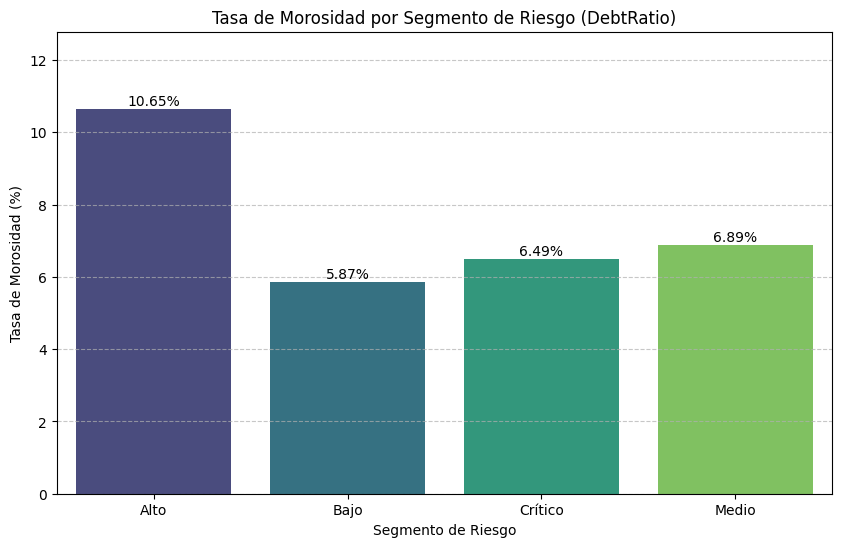

In [8]:
plt.figure(figsize=(10, 6))
sns.barplot(x=morosidad_segmento.index, y='tasa_morosidad_pct', data=morosidad_segmento, palette='viridis', hue=morosidad_segmento.index, legend=False)
plt.title('Tasa de Morosidad por Segmento de Riesgo (DebtRatio)')
plt.xlabel('Segmento de Riesgo')
plt.ylabel('Tasa de Morosidad (%)')
plt.ylim(0, morosidad_segmento['tasa_morosidad_pct'].max() * 1.2)
plt.grid(axis='y', linestyle='--', alpha=0.7)

for index, row in morosidad_segmento.iterrows():
    plt.text(index, row['tasa_morosidad_pct'] + 0.1, f"{row['tasa_morosidad_pct']:.2f}%", color='black', ha="center")

plt.show()

### ¿El ratio deuda/ingreso es un buen predictor de morosidad en este dataset?

Basándonos en el análisis y la visualización de la tasa de morosidad por segmento de riesgo (`segmento_riesgo`), podemos concluir lo siguiente:

**Sí, el ratio deuda/ingreso (`DebtRatio`) parece ser un buen predictor de morosidad en este dataset.**

**Razones:**

1.  **Diferencias Claras en la Tasa de Morosidad:** El gráfico de barras y la tabla `morosidad_segmento` muestran una clara tendencia: a medida que el ratio deuda/ingreso aumenta (de 'Bajo' a 'Alto'), la tasa de morosidad también tiende a aumentar significativamente. El segmento 'Alto' tiene la tasa más alta (10.65%), mientras que el 'Bajo' tiene la más baja (5.87%). Esta diferencia de casi el doble entre los extremos es un fuerte indicador.

2.  **Gradiente de Riesgo:** Se observa un gradiente de riesgo: `Bajo` (5.87%) < `Crítico` (6.49%) < `Medio` (6.89%) < `Alto` (10.65%). Aunque el segmento 'Crítico' no es el más alto en morosidad, su alta concentración de deuda es intrínsecamente un factor de riesgo. La progresión de la morosidad a lo largo de los segmentos definidos por el `DebtRatio` sugiere una relación directa y predictiva.

3.  **Coherencia con la Lógica de Negocio:** Financieramente, es lógico que un cliente con una mayor proporción de su ingreso dedicada al pago de deudas tenga una mayor probabilidad de caer en morosidad. Los resultados obtenidos confirman esta intuición de negocio.

En resumen, el `DebtRatio` es una variable clave que permite diferenciar y segmentar a los clientes según su nivel de riesgo de morosidad de manera efectiva, lo que lo convierte en un predictor valioso para modelos de riesgo crediticio.

## SQL: Análisis de morosidad por tramos de edad


In [9]:
conn = sqlite3.connect('memory:')
df.to_sql('creditos', conn, if_exists='replace', index=False)

QUERY1 = """
SELECT
    age_group,
    COUNT(*) AS total_clientes,
    SUM(SeriousDlqin2yrs) AS total_morosos,
    ROUND(AVG(SeriousDlqin2yrs)*100, 2) AS tasa_morosidad_pct,
    ROUND(AVG(MonthlyIncome), 2) AS ingreso_promedio,
    ROUND(AVG(DebtRatio), 2) AS ratio_deuda_ingreso
FROM
    creditos
GROUP BY
    age_group
ORDER BY
    tasa_morosidad_pct DESC
"""

df_sql = pd.read_sql_query(QUERY1, conn)
display(df_sql)

,age_group,total_clientes,total_morosos,tasa_morosidad_pct,ingreso_promedio,ratio_deuda_ingreso
0,<30,10757,1244,11.56,3153.24,96.74
1,30-45,40547,3775,9.31,6183.82,292.21
2,45-60,53635,3657,6.82,7388.05,421.92
3,>60,45060,1350,3.00,6285.52,386.86


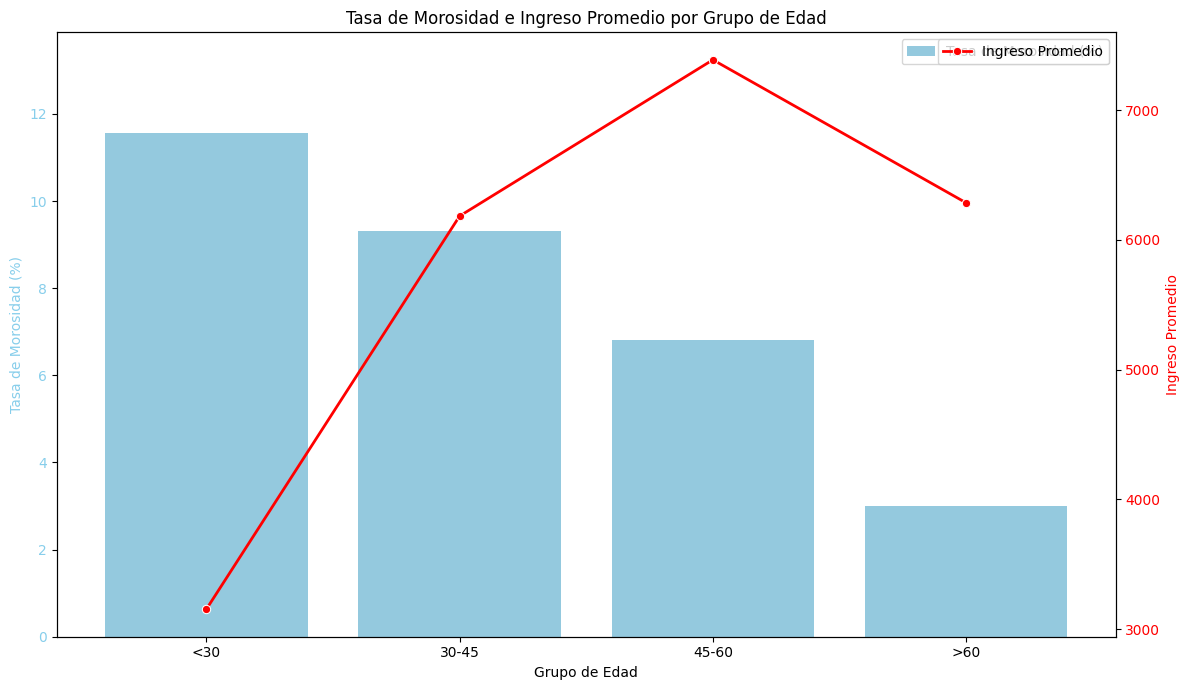

In [10]:
fig, ax1 = plt.subplots(figsize=(12, 7))

# Plotting Tasa de Morosidad on the first Y-axis
sns.barplot(x='age_group', y='tasa_morosidad_pct', data=df_sql, ax=ax1, color='skyblue', label='Tasa de Morosidad (%)')
ax1.set_xlabel('Grupo de Edad')
ax1.set_ylabel('Tasa de Morosidad (%)', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_ylim(0, df_sql['tasa_morosidad_pct'].max() * 1.2)

# Create a second Y-axis for Ingreso Promedio
ax2 = ax1.twinx()
sns.lineplot(x='age_group', y='ingreso_promedio', data=df_sql, ax=ax2, color='red', marker='o', linewidth=2, label='Ingreso Promedio')
ax2.set_ylabel('Ingreso Promedio', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('Tasa de Morosidad e Ingreso Promedio por Grupo de Edad')
fig.tight_layout()
plt.show()

### ¿Qué grupo de edad concentra mayor riesgo?

Basándonos en el análisis de la tabla `df_sql` y la visualización, podemos identificar claramente que:

El grupo de edad que concentra el **mayor riesgo de morosidad** es el de **`<30` años**, con una tasa de morosidad del **11.56%**.

Esto es significativamente más alto que los otros grupos, incluso a pesar de que su ingreso promedio es el más bajo. El riesgo disminuye progresivamente con la edad:

*   **`<30`:** 11.56% de morosidad
*   **`30-45`:** 9.31% de morosidad
*   **`45-60`:** 6.82% de morosidad
*   **`>60`:** 3.00% de morosidad

Esta tendencia es coherente con las expectativas en el sector financiero, donde los clientes más jóvenes a menudo tienen un historial crediticio más corto, menos activos y, potencialmente, menor estabilidad económica, lo que se traduce en un mayor riesgo de incumplimiento.

## Alerta temprana: clientes en zona crítica

,age_group,segmento_riesgo,total,morosos,tasa_pct,ingreso_promedio
0,30-45,Alto,4153,521,12.55,4833.15
1,<30,Crítico,2004,247,12.33,2165.40
2,<30,Alto,590,66,11.19,2310.43
3,45-60,Alto,4982,548,11.00,5578.05
4,30-45,Crítico,7664,794,10.36,4366.68
5,>60,Alto,2814,200,7.11,5045.73
6,45-60,Crítico,12358,873,7.06,5509.89
7,>60,Crítico,13340,380,2.85,4811.02


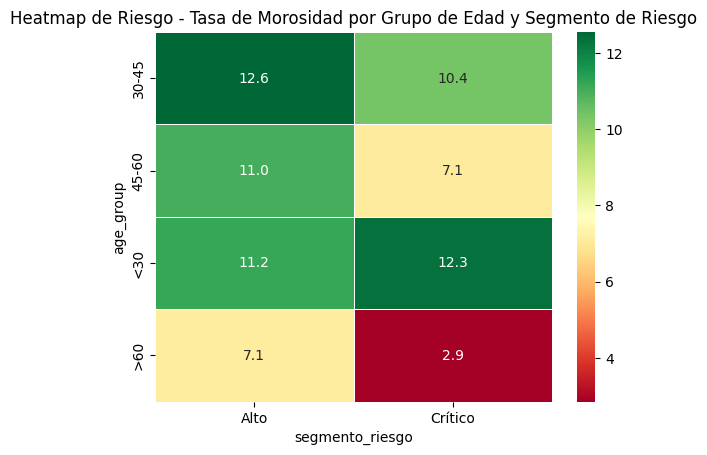

In [11]:
QUERY2 = """
SELECT
    age_group,
    segmento_riesgo,
    COUNT(*) AS total,
    SUM(SeriousDlqin2yrs) AS morosos,
    ROUND(AVG(SeriousDlqin2yrs)*100, 2) AS tasa_pct,
    ROUND(AVG(MonthlyIncome), 2) AS ingreso_promedio
FROM
    creditos
WHERE segmento_riesgo IN ('Alto', 'Crítico')
GROUP BY
    age_group, segmento_riesgo
ORDER BY
    tasa_pct DESC
"""
df_alerta = pd.read_sql_query(QUERY2, conn)
display(df_alerta)

# Heatmap de riesgo
pivot_df = df_alerta.pivot_table(
    index='age_group', columns='segmento_riesgo', values='tasa_pct')
sns.heatmap(pivot_df, annot=True, fmt='.1f', cmap='RdYGn_r', linewidths=0.5)
plt.title('Heatmap de Riesgo - Tasa de Morosidad por Grupo de Edad y Segmento de Riesgo')
plt.show()

## Conclusiones Ejecutivas: Análisis de Riesgo de Crédito

Como Analista de Riesgo, y basándome en el análisis detallado del comportamiento de pagos de la cartera de clientes, presento las siguientes conclusiones clave para el Gerente de Riesgo:

### 1. ¿Cuál es la tasa de morosidad global?
La **tasa de morosidad global** de la cartera es del **6.68%**. Este es el punto de referencia general contra el cual se deben evaluar los segmentos específicos.

### 2. ¿Qué combinación edad + segmento tiene mayor riesgo?
El análisis ha revelado que la combinación de mayor riesgo es el grupo de edad de **`30-45 años` en el `segmento_riesgo 'Alto'`**, con una tasa de morosidad del **12.55%**. Le sigue de cerca el grupo de edad de **`<30 años` en el `segmento_riesgo 'Crítico'`**, con un **12.33%**. Esto indica que los clientes jóvenes y de mediana edad con alta carga de deuda son los más propensos a la morosidad.

### 3. ¿Qué umbral de alerta temprana recomendás al Gerente de Riesgo?
Recomiendo establecer un **umbral de alerta temprana** para aquellos clientes cuyo **`DebtRatio` se encuentre en el `segmento 'Alto'` (entre 0.6 y 1.0) o `Crítico` (mayor a 1.0)**. Particularmente, se debe poner un foco especial en los clientes de estos segmentos que además pertenezcan a los grupos de edad **`<30 años` y `30-45 años`**, ya que son los que presentan tasas de morosidad significativamente superiores a la media global. Estos clientes deberían ser objeto de un monitoreo más frecuente o de programas de intervención temprana.

### 4. ¿Cómo aplicar un criterio de aceptación/rechazo?
Desde una perspectiva de gestión de riesgos basada en estándares ISO (como ISO 31000), aplicaríamos un criterio de aceptación/rechazo de la siguiente manera:

*   **Definición de Criterios Claros:** Estableceríamos umbrales de `DebtRatio` para la aceptación automática, la revisión manual y el rechazo automático. Por ejemplo:
    *   **Aceptación Automática:** `DebtRatio < 0.3` (`segmento_riesgo 'Bajo'`), asumiendo que cumplen otros criterios mínimos.
    *   **Revisión Manual (con Alerta Temprana):** `DebtRatio entre 0.3 y 1.0` (`segmento_riesgo 'Medio'` y `'Alto'`). Estos casos requerirían un análisis más profundo de su historial crediticio, capacidad de pago y estabilidad laboral. Aquí, los grupos de edad de alto riesgo serían una bandera roja adicional.
    *   **Rechazo Automático o Revisión Muy Estricta:** `DebtRatio > 1.0` (`segmento_riesgo 'Crítico'`). Para estos clientes, el riesgo es intrínsecamente muy alto, y la aceptación solo se consideraría bajo condiciones muy excepcionales y con garantías adicionales.

*   **Monitoreo Continuo:** Implementaríamos un proceso de monitoreo continuo del `DebtRatio` y la edad del cliente en relación con los umbrales de morosidad identificados. Cualquier cambio significativo que mueva a un cliente a un segmento de mayor riesgo activaría una alerta y una posible revisión de sus condiciones.

*   **Evaluación y Revisión Periódica:** El modelo y los umbrales de riesgo se revisarían periódicamente (por ejemplo, anualmente o ante cambios significativos en el mercado) para asegurar su efectividad y cumplimiento con los objetivos de negocio y la tolerancia al riesgo de la organización.